# Inspect OpenCap NWB output

This notebook checks an NWB file generated by `opencap-to-nwb`.

It does **not** perform conversion. It only opens the output file, prints basic metadata, checks the stored behavior interfaces, and plots a small sample of the movement data.

## 1. Imports and file selection

Set `NWB_PATH` to whichever converted file you want to inspect.

In [54]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
from pynwb import NWBHDF5IO


def find_repo_root(start: Path | None = None) -> Path:
    """Find the project root from a notebook launched in the root or notebooks/ folder."""
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() or (candidate / "test_output").exists():
            return candidate

    return start


REPO_ROOT = find_repo_root()

# Change this to subject0_asym.nwb if you want to inspect the other trial.
NWB_PATH = REPO_ROOT / "test_output" / "subject0_squats.nwb"

print("repo root:", REPO_ROOT)
print("NWB path:", NWB_PATH)
print("exists:", NWB_PATH.exists())

if not NWB_PATH.exists():
    raise FileNotFoundError(
        f"NWB file not found: {NWB_PATH}\n"
        "Run the converter first, for example:\n"
        "opencap-to-nwb --input test_data/subject0 --trial Squats_0 --output test_output/subject0_squats.nwb"
    )

repo root: /home/phil/Documents/code/opencap-to-nwb
NWB path: /home/phil/Documents/code/opencap-to-nwb/test_output/subject0_squats.nwb
exists: True


## 2. Open the NWB file

This keeps the file handle open so later cells can read lazy HDF5 datasets.

In [55]:
io = NWBHDF5IO(str(NWB_PATH), "r")
nwb = io.read()

print("loaded:", NWB_PATH.name)

loaded: subject0_squats.nwb


## 3. Basic NWB metadata

In [56]:
subject = nwb.subject

print("identifier:", nwb.identifier)
print("session_id:", nwb.session_id)
print("session_description:", nwb.session_description)
print("experiment_description:", nwb.experiment_description)

if subject is not None:
    print("subject_id:", subject.subject_id)
    print("sex:", subject.sex)
    print("species:", subject.species)
    print("subject description:", subject.description)
else:
    print("subject: None")

identifier: subject0-subject0-Squats_0
session_id: subject0
session_description: OpenCap/OpenSim-style movement outputs converted to NWB. V1 stores pose and joint angles as generic TimeSeries. Activity: squat.
experiment_description: OpenCap to NWB conversion.
subject_id: subject0
sex: M
species: Homo sapiens
subject description: height_m=1.78; mass_kg=72.0; trial_id=Squats_0; activity=squat


## 4. Processing modules and behavior interfaces

In [57]:
print("processing modules:", list(nwb.processing.keys()))

behavior = nwb.processing["behavior"]
print("behavior description:", behavior.description)
print("behavior data interfaces:", list(behavior.data_interfaces.keys()))

pose = behavior.data_interfaces["OpenCapPose3D"]
joint_angles = behavior.data_interfaces["OpenCapJointAngles"]

for name, ts in behavior.data_interfaces.items():
    print(f"\n{name}")
    print("  data shape:", tuple(ts.data.shape))
    print("  unit:", ts.unit)
    print("  comments:", ts.comments)
    print("  description:", ts.description[:500] + ("..." if len(ts.description) > 500 else ""))

processing modules: ['behavior']
behavior description: OpenCap-derived pose and joint-angle data.
behavior data interfaces: ['OpenCapJointAngles', 'OpenCapPose3D']

OpenCapJointAngles
  data shape: (832, 35)
  unit: mixed or unknown
  comments: Rows are timepoints. Columns are MOT columns excluding time.
  description: Joint angle / coordinate time series parsed from an OpenCap/OpenSim-style MOT file. Columns: pelvis_tilt, pelvis_list, pelvis_rotation, pelvis_tx, pelvis_ty, pelvis_tz, hip_flexion_r, hip_adduction_r, hip_rotation_r, knee_angle_r, knee_angle_r_beta, ankle_angle_r, subtalar_angle_r, mtp_angle_r, hip_flexion_l, hip_adduction_l, hip_rotation_l, knee_angle_l, knee_angle_l_beta, ankle_angle_l, subtalar_angle_l, mtp_angle_l, lumbar_extension, lumbar_bending, lumbar_rotation, arm_flex_r, arm_add_r, arm...

OpenCapPose3D
  data shape: (832, 189)
  unit: m
  comments: Rows are timepoints. Columns are marker XYZ coordinates flattened as marker_x, marker_y, marker_z.
  description:

## 5. Timestamp sanity check

In [58]:
def summarize_timestamps(ts, name: str) -> None:
    timestamps = np.asarray(ts.timestamps[:])

    print(name)
    print("  count:", len(timestamps))
    print("  first 5:", timestamps[:5])
    print("  final:", timestamps[-1])
    print("  strictly increasing:", bool(np.all(np.diff(timestamps) > 0)))


summarize_timestamps(pose, "OpenCapPose3D timestamps")
summarize_timestamps(joint_angles, "OpenCapJointAngles timestamps")

OpenCapPose3D timestamps
  count: 832
  first 5: [0.        0.0166667 0.0333333 0.05      0.0666667]
  final: 13.85
  strictly increasing: True
OpenCapJointAngles timestamps
  count: 832
  first 5: [0.        0.0166667 0.0333333 0.05      0.0666667]
  final: 13.85
  strictly increasing: True


## 6. Column labels parsed from descriptions

The V1 writer stores data as generic NWB `TimeSeries`. Column names are currently embedded in the `description` text.

In [59]:
def extract_columns_from_description(description: str) -> list[str]:
    """Extract the comma-separated column list from the TimeSeries description."""
    match = re.search(r"Columns: (.*?). Source file:", description)
    if match is None:
        return []
    return [item.strip() for item in match.group(1).split(",") if item.strip()]


pose_columns = extract_columns_from_description(pose.description)
joint_columns = extract_columns_from_description(joint_angles.description)

print("pose column count:", len(pose_columns))
print("first 12 pose columns:", pose_columns[:12])
print("joint angle column count:", len(joint_columns))
print("first 12 joint angle columns:", joint_columns[:12])

pose column count: 189
first 12 pose columns: ['Neck_x', 'Neck_y', 'Neck_z', 'RShoulder_x', 'RShoulder_y', 'RShoulder_z', 'RElbow_x', 'RElbow_y', 'RElbow_z', 'RWrist_x', 'RWrist_y', 'RWrist_z']
joint angle column count: 35
first 12 joint angle columns: ['pelvis_tilt', 'pelvis_list', 'pelvis_rotation', 'pelvis_tx', 'pelvis_ty', 'pelvis_tz', 'hip_flexion_r', 'hip_adduction_r', 'hip_rotation_r', 'knee_angle_r', 'knee_angle_r_beta', 'ankle_angle_r']


## 7. Plot one pose coordinate

This plots the first pose coordinate column. For the current writer, pose data are flattened as:

`marker_x, marker_y, marker_z, next_marker_x, next_marker_y, next_marker_z, ...`

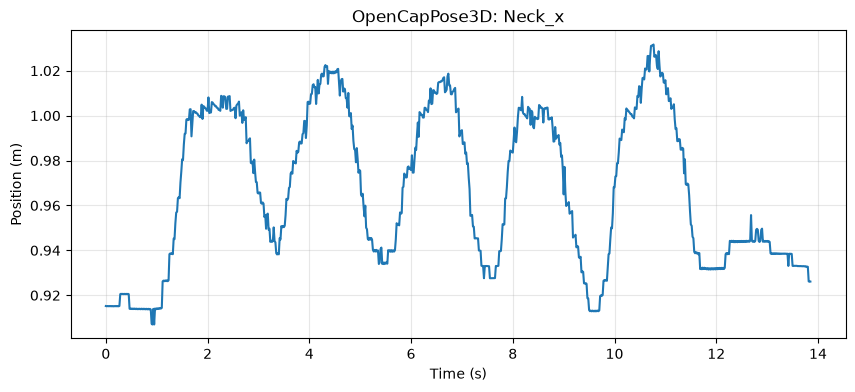

In [60]:
pose_timestamps = np.asarray(pose.timestamps[:])
pose_data = np.asarray(pose.data[:])

pose_column_index = 0
pose_label = pose_columns[pose_column_index] if pose_columns else f"column {pose_column_index}"

plt.figure(figsize=(10, 4))
plt.plot(pose_timestamps, pose_data[:, pose_column_index])
plt.xlabel("Time (s)")
plt.ylabel(f"Position ({pose.unit})")
plt.title(f"OpenCapPose3D: {pose_label}")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Plot one joint-angle / OpenSim coordinate series

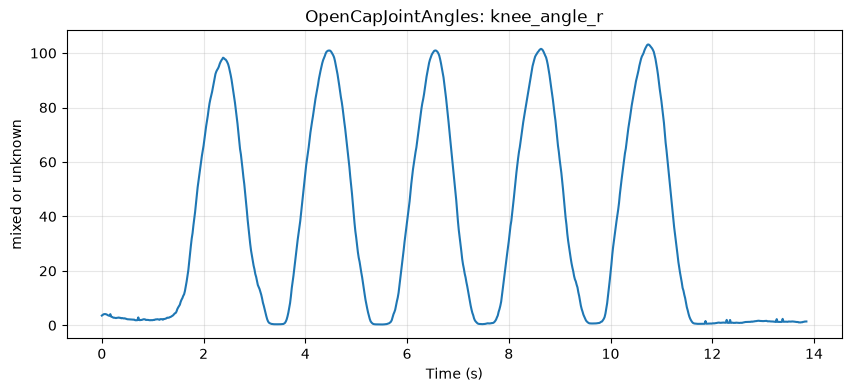

In [61]:
joint_timestamps = np.asarray(joint_angles.timestamps[:])
joint_data = np.asarray(joint_angles.data[:])

# Prefer a knee angle if available; otherwise use the first joint-angle column.
preferred = [i for i, name in enumerate(joint_columns) if "knee" in name.lower()]
joint_column_index = preferred[0] if preferred else 0
joint_label = joint_columns[joint_column_index] if joint_columns else f"column {joint_column_index}"

plt.figure(figsize=(10, 4))
plt.plot(joint_timestamps, joint_data[:, joint_column_index])
plt.xlabel("Time (s)")
plt.ylabel(joint_angles.unit)
plt.title(f"OpenCapJointAngles: {joint_label}")
plt.grid(True, alpha=0.3)
plt.show()

## 9. Optional: inspect the other trial

To inspect `subject0_asym.nwb`, change the `NWB_PATH` assignment in the first code cell to:

```python
NWB_PATH = REPO_ROOT / "test_output" / "subject0_asym.nwb"
```

Then restart the notebook kernel and run all cells again.

## 10. Close the file

Run this when you are done inspecting the file.

In [62]:
io.close()

## 11. Inspect NWB file content

In [63]:
from pathlib import Path
from pynwb import NWBHDF5IO

nwb_path = Path("../test_output/subject0_asym.nwb")

print("exists:", nwb_path.exists())
print("path:", nwb_path.resolve())

with NWBHDF5IO(str(nwb_path), "r") as io:
    nwbfile = io.read()

    print(nwbfile)

    behavior = nwbfile.processing["behavior"]

    pose = behavior.data_interfaces["OpenCapPose3D"]
    joint_angles = behavior.data_interfaces["OpenCapJointAngles"]

    print("pose shape:", pose.data.shape)
    print("joint angles shape:", joint_angles.data.shape)

    print("pose timestamps:", pose.timestamps[:5])
    print("joint angle timestamps:", joint_angles.timestamps[:5])

    print("pose final timestamp:", pose.timestamps[-1])
    print("joint final timestamp:", joint_angles.timestamps[-1])

exists: True
path: /home/phil/Documents/code/opencap-to-nwb/test_output/subject0_asym.nwb
root pynwb.file.NWBFile at 0x138765615421392
Fields:
  experiment_description: OpenCap to NWB conversion.
  file_create_date: [datetime.datetime(2026, 7, 8, 12, 12, 6, 586201, tzinfo=tzoffset(None, -14400))]
  identifier: subject0-subject0-Asym_0
  notes: Created by opencap-to-nwb scaffold. Validate against real OpenCap output before scientific use.
  processing: {
    behavior <class 'pynwb.base.ProcessingModule'>
  }
  scratch: {
    opencap_source_files <class 'pynwb.core.ScratchData'>
  }
  session_description: OpenCap/OpenSim-style movement outputs converted to NWB. V1 stores pose and joint angles as generic TimeSeries. Activity: asymmetric squat.
  session_id: subject0
  session_start_time: 2026-07-08 16:12:06.585947+00:00
  subject: subject pynwb.file.Subject at 0x138765611178064
Fields:
  age__reference: birth
  description: height_m=1.78; mass_kg=72.0; trial_id=Asym_0; activity=asymmetric

In [64]:
from pynwb import NWBHDF5IO

path = "../test_output/subject0_squats.nwb"

with NWBHDF5IO(path, "r") as io:
    nwb = io.read()
    print(nwb)
    print("subject_id:", nwb.subject.subject_id)
    print("session_id:", nwb.session_id)

    behavior = nwb.processing["behavior"]
    for name, obj in behavior.data_interfaces.items():
        print(name, obj.data.shape)


root pynwb.file.NWBFile at 0x138765611331536
Fields:
  experiment_description: OpenCap to NWB conversion.
  file_create_date: [datetime.datetime(2026, 7, 8, 12, 11, 56, 178181, tzinfo=tzoffset(None, -14400))]
  identifier: subject0-subject0-Squats_0
  notes: Created by opencap-to-nwb scaffold. Validate against real OpenCap output before scientific use.
  processing: {
    behavior <class 'pynwb.base.ProcessingModule'>
  }
  scratch: {
    opencap_source_files <class 'pynwb.core.ScratchData'>
  }
  session_description: OpenCap/OpenSim-style movement outputs converted to NWB. V1 stores pose and joint angles as generic TimeSeries. Activity: squat.
  session_id: subject0
  session_start_time: 2026-07-08 16:11:56.178001+00:00
  subject: subject pynwb.file.Subject at 0x138765612885840
Fields:
  age__reference: birth
  description: height_m=1.78; mass_kg=72.0; trial_id=Squats_0; activity=squat
  sex: M
  species: Homo sapiens
  subject_id: subject0

  timestamps_reference_time: 2026-07-08 16: